# Load Data

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

from joint_tof_opt import (
    AdditiveGaussianToFModifier,
    ToFData,
    generate_tof,
)
from joint_tof_opt.plotting import load_plot_config

file_idx = 4
ppath_file = Path(f"../data/experiment_{file_idx:04d}.npz")
tof_dataset_path = Path(f"../data/generated_tof_set_{ppath_file.stem}.npz")
gen_config: dict = yaml.safe_load(open("../experiments/tof_config.yaml"))
generate_tof(ppath_file, gen_config, tof_dataset_path, True, True)
tof_data = ToFData.from_npz(tof_dataset_path)
load_plot_config()

## Additive Gauss Noise

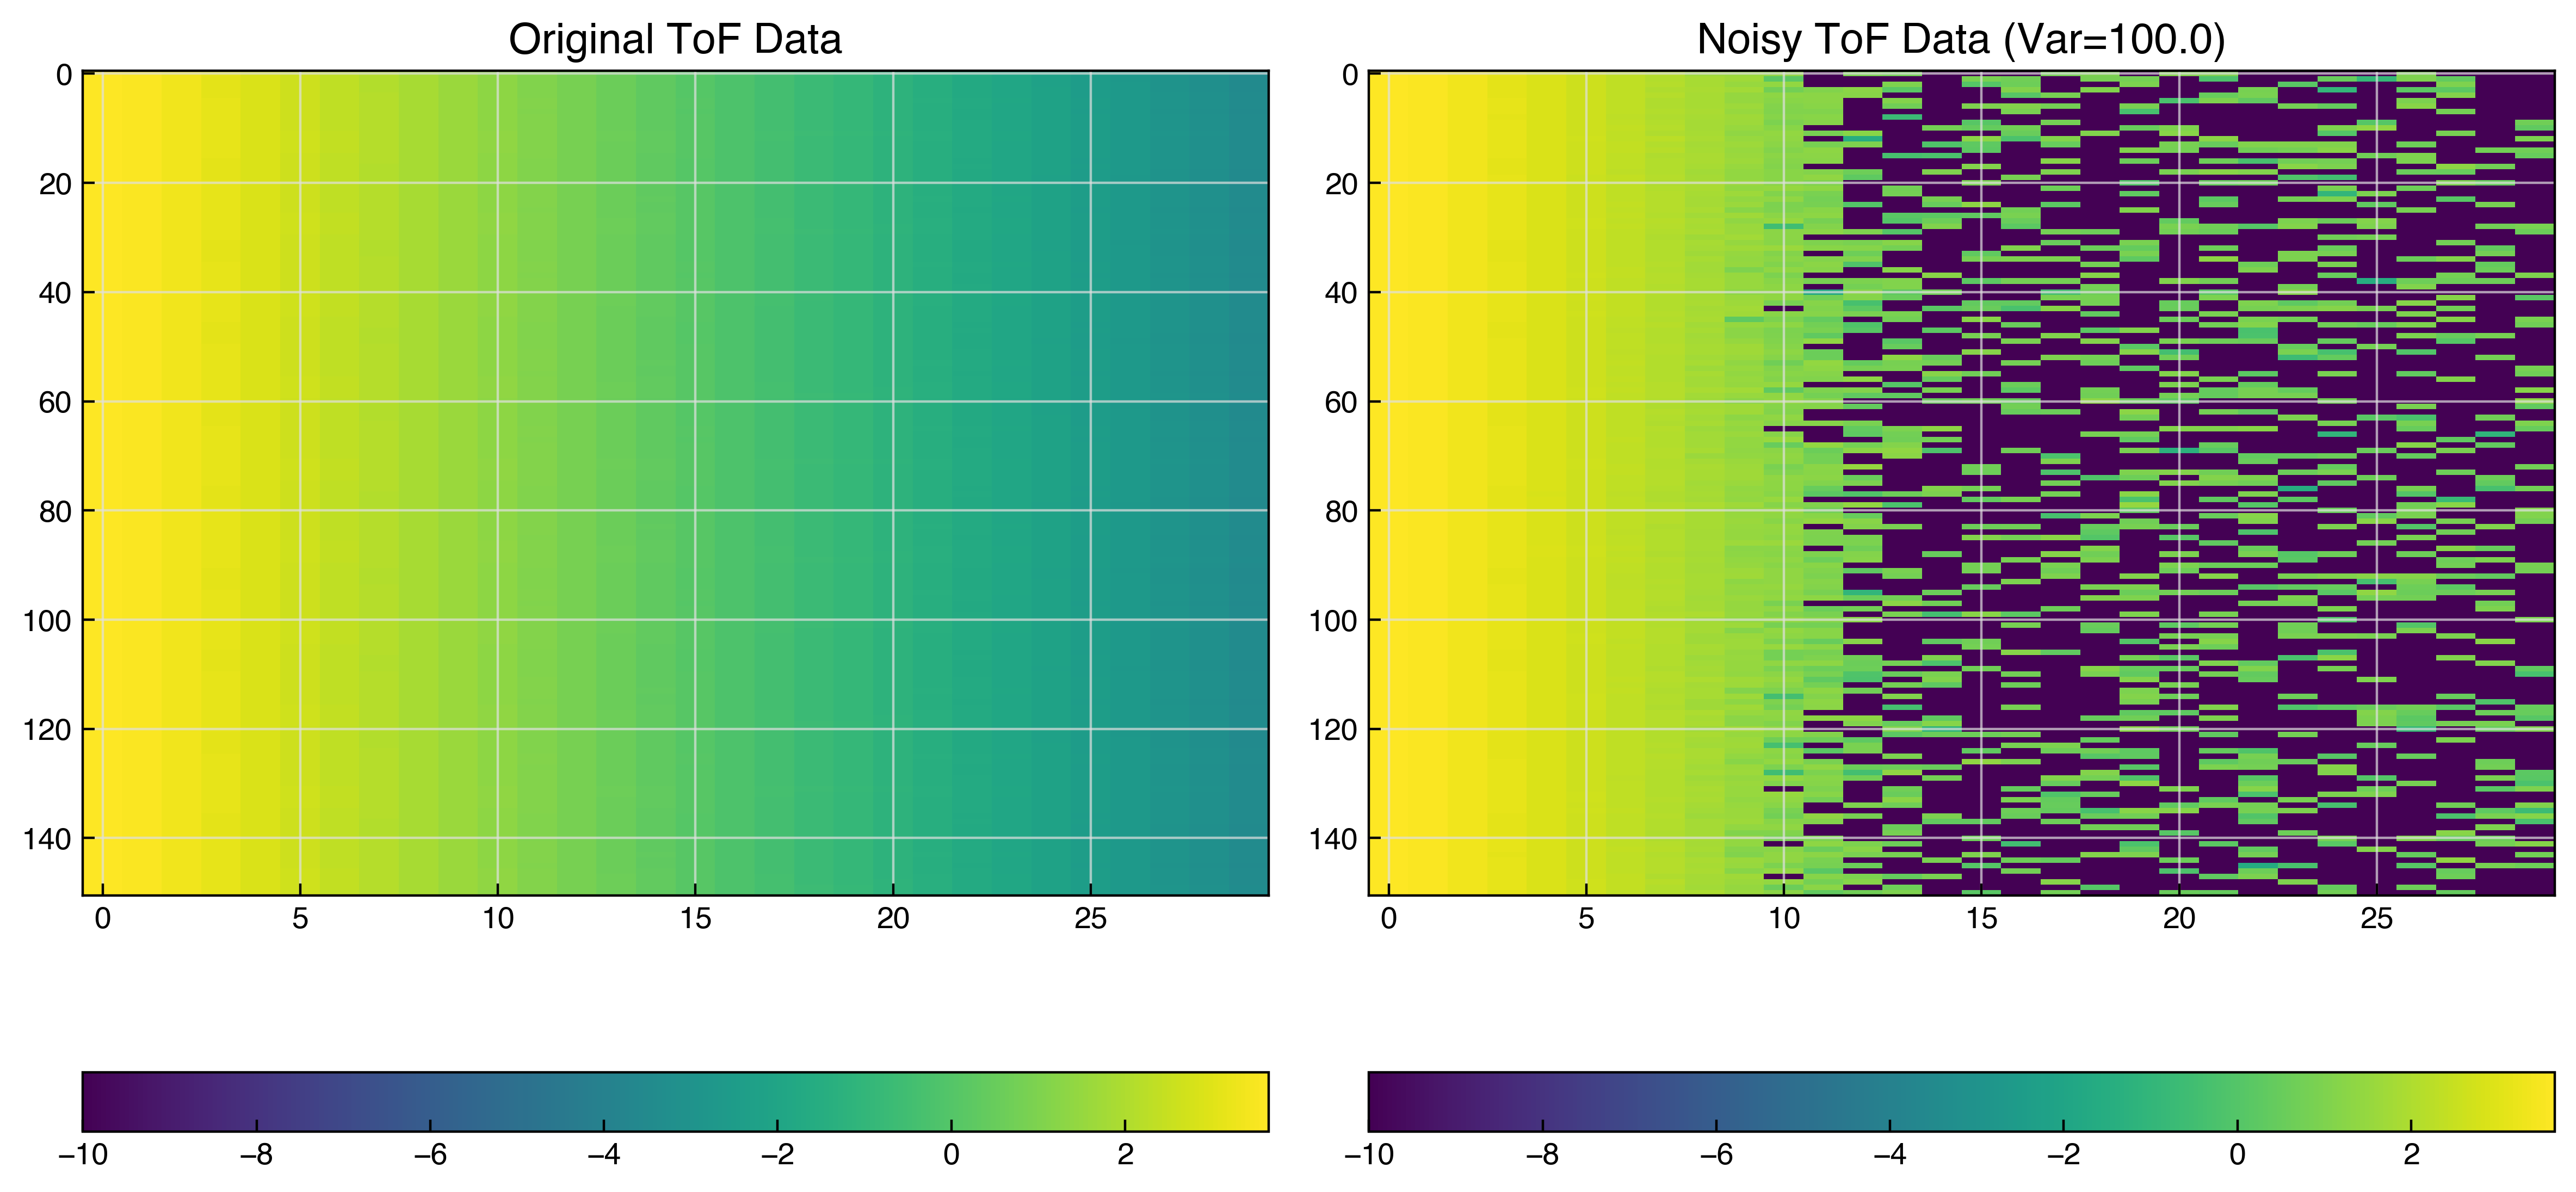

In [31]:
EPS = 1e-10
noise_var = 100.0
noise_mod = AdditiveGaussianToFModifier(noise_var)
tof_noisy = noise_mod.modify(tof_data)

log_orig = np.log10(tof_data.tof_series.numpy() + EPS)
log_noisy = np.log10(tof_noisy.tof_series.numpy() + EPS)
vmin = min(log_orig.min(), log_noisy.min())
vmax = max(log_orig.max(), log_noisy.max())

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im0 = ax[0].imshow(log_orig, aspect="auto", vmin=vmin, vmax=vmax, cmap="viridis")
im1 = ax[1].imshow(log_noisy, aspect="auto", vmin=vmin, vmax=vmax, cmap="viridis")
ax[0].set_title("Original ToF Data")
ax[1].set_title(f"Noisy ToF Data (Var={noise_var})")
fig.colorbar(im0, ax=ax[0], orientation="horizontal", pad=0.15)
fig.colorbar(im1, ax=ax[1], orientation="horizontal", pad=0.15)
plt.tight_layout()
plt.show()

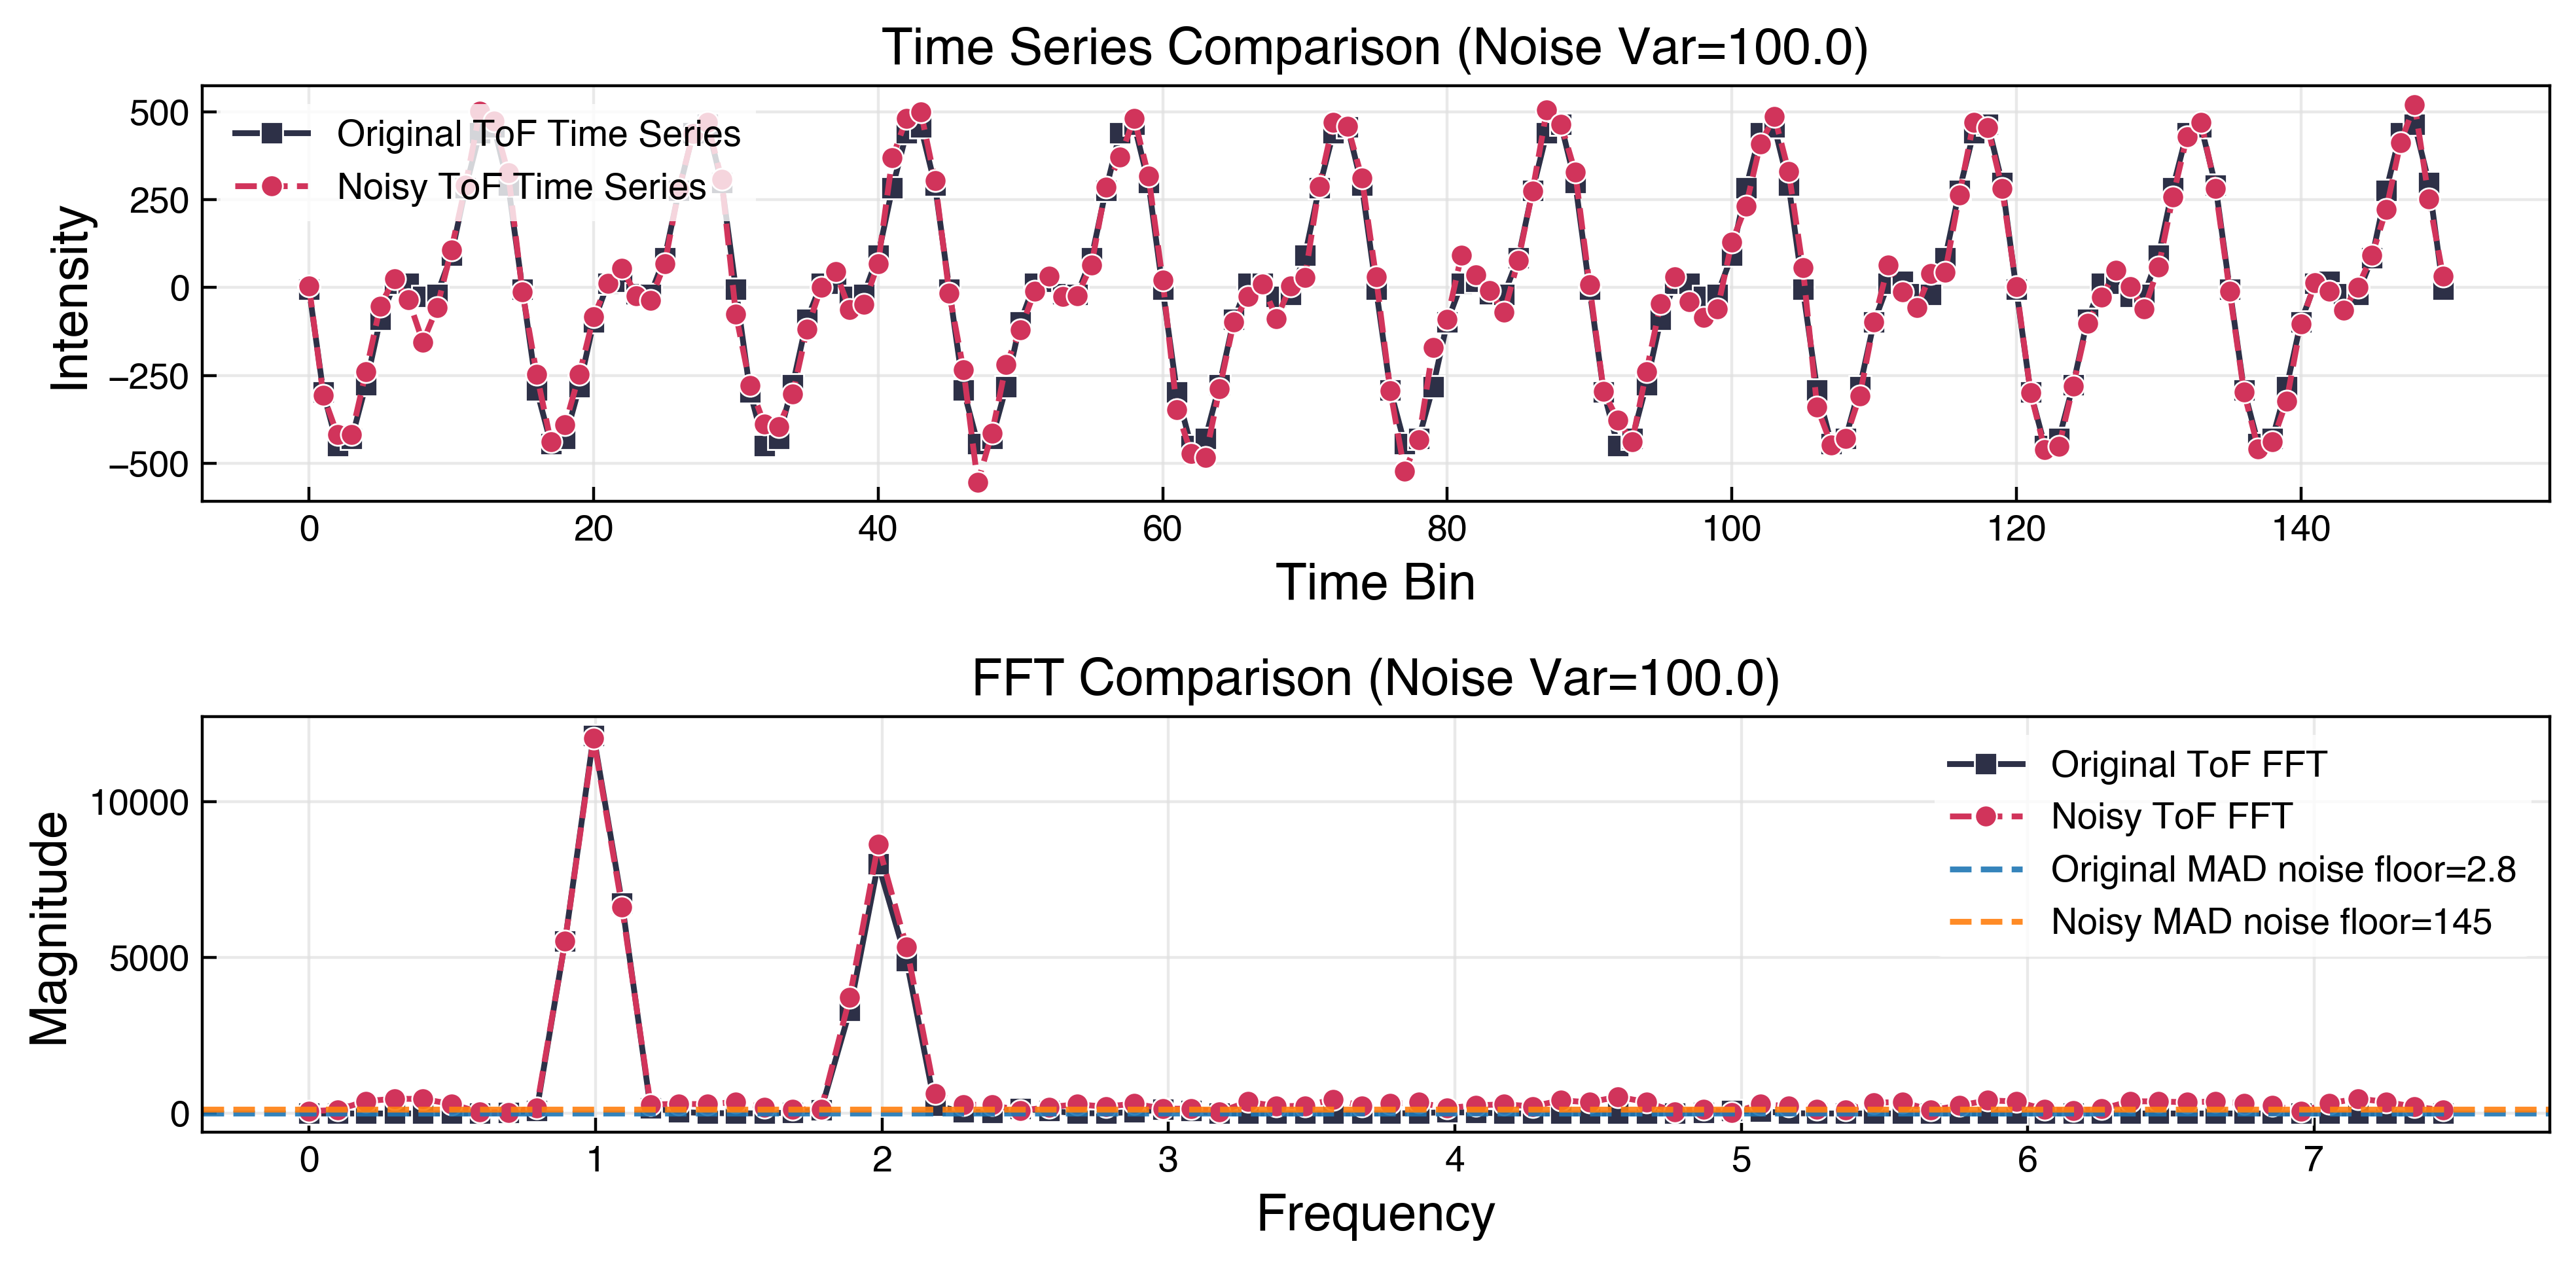

Original FFT MAD noise floor: 2.79783
Noisy FFT MAD noise floor: 144.523


In [32]:
true_time_series = tof_data.tof_series.sum(dim=1).numpy()
true_time_series -= np.mean(true_time_series)
noisy_time_series = tof_noisy.tof_series.sum(dim=1).numpy()
noisy_time_series -= np.mean(noisy_time_series)

fig, axses = plt.subplots(2, 1, figsize=(10, 5))
plt.sca(axses[0])
plt.plot(true_time_series, label="Original ToF Time Series")
plt.plot(noisy_time_series, label="Noisy ToF Time Series")
plt.title(f"Time Series Comparison (Noise Var={noise_var})")
plt.xlabel("Time Bin")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()

plt.sca(axses[1])
fft_orig = np.fft.rfft(true_time_series * np.hanning(len(true_time_series)))
fft_noisy = np.fft.rfft(noisy_time_series * np.hanning(len(noisy_time_series)))
fs = gen_config["sampling_rate"]
freqs = np.fft.rfftfreq(len(true_time_series), d=1 / fs)

mag_orig = np.abs(fft_orig)
mag_noisy = np.abs(fft_noisy)

def mad_noise_floor(fft_mag: np.ndarray) -> float:
    # Skip DC bin so the baseline reflects oscillatory spectral noise.
    spectrum = fft_mag[1:] if fft_mag.shape[0] > 1 else fft_mag
    median_fft = np.median(spectrum)
    mad_fft = np.median(np.abs(spectrum - median_fft))
    return float(1.4826 * mad_fft)

noise_floor_orig = mad_noise_floor(mag_orig)
noise_floor_noisy = mad_noise_floor(mag_noisy)

plt.plot(freqs, mag_orig, label="Original ToF FFT")
plt.plot(freqs, mag_noisy, label="Noisy ToF FFT")
plt.axhline(
    noise_floor_orig,
    color="tab:blue",
    linestyle="--",
    alpha=0.9,
    label=f"Original MAD noise floor={noise_floor_orig:.3g}",
)
plt.axhline(
    noise_floor_noisy,
    color="tab:orange",
    linestyle="--",
    alpha=0.9,
    label=f"Noisy MAD noise floor={noise_floor_noisy:.3g}",
)
plt.title(f"FFT Comparison (Noise Var={noise_var})")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Original FFT MAD noise floor: {noise_floor_orig:.6g}")
print(f"Noisy FFT MAD noise floor: {noise_floor_noisy:.6g}")